# Projeto Final — CVRP: Otimização de Rotas de Entrega
**MBA em Ciência de Dados — UNIFOR**

**Disciplina: Pesquisa Operacional e Otimização em IA**

**Problema:** Uma empresa de logística em Fortaleza/CE possui 1 centro de distribuição e precisa
atender 15 clientes usando 2 veículos com capacidade máxima de 500kg cada.

**Objetivo:** Minimizar a distância total percorrida, utilizando coordenadas GPS reais e
distâncias calculadas por rotas rodoviárias (OSRM).

## 1. Instalação e Imports

In [1]:
!pip install pulp matplotlib numpy requests -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
import requests
import random

random.seed(42)
np.random.seed(42)

## 2. Dados Reais — Coordenadas GPS (Fortaleza/CE)

In [3]:
# Pontos reais: ID 0 = depósito, IDs 1-15 = clientes
pontos_info = [
    {'id': 0,  'nome': 'CD (Depósito)',                    'endereco': 'Rua Lineu Jucá, 421',                'lat': -3.7682832382, 'lon': -38.5350103748},
    {'id': 1,  'nome': 'C1',  'endereco': 'Rua Jaime Benévolo, 107',             'lat': -3.7331758870, 'lon': -38.5258148616},
    {'id': 2,  'nome': 'C2',  'endereco': 'Av. Visconde do Rio Branco, 6181',    'lat': -3.7564784384, 'lon': -38.5200069203},
    {'id': 3,  'nome': 'C3',  'endereco': 'Rodovia BR116 km 4',                  'lat': -3.9261676266, 'lon': -38.5074990896},
    {'id': 4,  'nome': 'C4',  'endereco': 'Av. Juarez Correia Lima, 179',        'lat': -4.1263074626, 'lon': -38.4840194637},
    {'id': 5,  'nome': 'C5',  'endereco': 'Rua Júlio da Silveira, 581',          'lat': -3.7579874751, 'lon': -38.5400643608},
    {'id': 6,  'nome': 'C6',  'endereco': 'Rua França, 1216',                    'lat': -3.7940468685, 'lon': -38.5642590203},
    {'id': 7,  'nome': 'C7',  'endereco': 'Av. Presidente Costa e Silva, 854',   'lat': -3.8124470892, 'lon': -38.5726046491},
    {'id': 8,  'nome': 'C8',  'endereco': 'Travessa 12, S/N Alto Alegre 1',      'lat': -3.8271900929, 'lon': -38.6083204907},
    {'id': 9,  'nome': 'C9',  'endereco': 'Rua Coronel Fabriciano, S/N',         'lat': -3.783883677,  'lon': -38.6032980651},
    {'id': 10, 'nome': 'C10', 'endereco': 'Rua Luiz Francisco Xavier, 520',      'lat': -3.8462996027, 'lon': -38.487959178},
    {'id': 11, 'nome': 'C11', 'endereco': 'Rodovia BR222, S/N km 19',            'lat': -3.763100416,  'lon': -38.6737800715},
    {'id': 12, 'nome': 'C12', 'endereco': 'Fazenda Santa Rosa, S/N',             'lat': -3.7040316296, 'lon': -38.7934578492},
    {'id': 13, 'nome': 'C13', 'endereco': 'Av. Lineu Machado, 375',             'lat': -3.7579767694, 'lon': -38.5400858184},
    {'id': 14, 'nome': 'C14', 'endereco': 'Rodovia BR116, km 6',                'lat': -3.7992343806, 'lon': -38.5054278268},
    {'id': 15, 'nome': 'C15', 'endereco': 'Rua Doralice Costa, 184',            'lat': -3.7704649896, 'lon': -38.4941188174},
]

N_CLIENTES = 15
N_VEICULOS = 2
CAPACIDADE = 500  # kg por veículo
CUSTO_POR_KM = 3.50  # R$/km
SALARIO_MOTORISTA = 3000.00  # R$/mês
DIAS_UTEIS_MES = 22

# Extrair coordenadas e nomes
nomes = [p['nome'] for p in pontos_info]
coordenadas_gps = [(p['lat'], p['lon']) for p in pontos_info]

# Gerar demandas (entre 96% e 100% da capacidade total para forçar rotas apertadas)
CAPACIDADE_TOTAL = N_VEICULOS * CAPACIDADE
DEMANDA_ALVO = CAPACIDADE_TOTAL * random.uniform(0.96, 0.99)

demandas_brutas = [random.randint(30, 100) for _ in range(N_CLIENTES)]
soma_bruta = sum(demandas_brutas)
fator = DEMANDA_ALVO / soma_bruta
demandas_brutas = [max(20, int(d * fator)) for d in demandas_brutas]

while sum(demandas_brutas) > CAPACIDADE_TOTAL:
    idx_max = demandas_brutas.index(max(demandas_brutas))
    demandas_brutas[idx_max] -= 1

demandas = [0] + demandas_brutas

print('=' * 70)
print(f'{"ID":<5} {"Nome":<25} {"Demanda (kg)":<15} {"Endereço"}')
print('=' * 70)
for i, p in enumerate(pontos_info):
    print(f'{i:<5} {nomes[i]:<25} {demandas[i]:<15} {p["endereco"]}')
print('=' * 70)
print(f'Demanda total: {sum(demandas)} kg')
print(f'Capacidade total frota: {CAPACIDADE_TOTAL} kg')
print(f'Custo por km: R$ {CUSTO_POR_KM:.2f}')
print(f'Salário por motorista: R$ {SALARIO_MOTORISTA:.2f}/mês')

ID    Nome                      Demanda (kg)    Endereço
0     CD (Depósito)             0               Rua Lineu Jucá, 421
1     C1                        38              Rua Jaime Benévolo, 107
2     C2                        74              Av. Visconde do Rio Branco, 6181
3     C3                        70              Rodovia BR116 km 4
4     C4                        66              Av. Juarez Correia Lima, 179
5     C5                        54              Rua Júlio da Silveira, 581
6     C6                        49              Rua França, 1216
7     C7                        114             Av. Presidente Costa e Silva, 854
8     C8                        47              Travessa 12, S/N Alto Alegre 1
9     C9                        96              Rua Coronel Fabriciano, S/N
10    C10                       39              Rua Luiz Francisco Xavier, 520
11    C11                       38              Rodovia BR222, S/N km 19
12    C12                       47              F

## 3. Matriz de Distâncias Reais (OSRM API)

In [4]:
def obter_matriz_distancias_osrm(coordenadas_gps):
    """
    Usa a API pública do OSRM para calcular a matriz de distâncias
    reais por estrada entre todos os pontos.
    Coordenadas: lista de tuplas (lat, lon)
    Retorna: matriz NxN com distâncias em km
    """
    # OSRM espera lon,lat (invertido!)
    coords_str = ';'.join([f'{lon},{lat}' for lat, lon in coordenadas_gps])
    
    url = f'http://router.project-osrm.org/table/v1/driving/{coords_str}'
    params = {'annotations': 'distance'}
    
    print('Consultando API OSRM para distâncias reais por estrada...')
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        raise Exception(f'Erro na API OSRM: {response.status_code}')
    
    data = response.json()
    
    if data['code'] != 'Ok':
        raise Exception(f'OSRM retornou erro: {data["code"]}')
    
    # Converter de metros para km e arredondar
    matriz_metros = data['distances']
    n = len(coordenadas_gps)
    matriz_km = [[round(matriz_metros[i][j] / 1000, 2) for j in range(n)] for i in range(n)]
    
    print(f'✅ Matriz {n}x{n} de distâncias reais obtida com sucesso!')
    return matriz_km

N = len(coordenadas_gps)  # 16 pontos (CD + 15 clientes)

try:
    dist = obter_matriz_distancias_osrm(coordenadas_gps)
    print('\nUsando distâncias REAIS por estrada (OSRM)')
except Exception as e:
    print(f'\n⚠️ Falha ao consultar OSRM: {e}')
    print('Usando distâncias euclidianas como fallback...\n')
    
    # Fallback: distância euclidiana aproximada (graus -> km)
    def distancia_euclidiana_km(p1, p2):
        # Aproximação: 1 grau ≈ 111 km
        dlat = (p1[0] - p2[0]) * 111
        dlon = (p1[1] - p2[1]) * 111 * np.cos(np.radians((p1[0] + p2[0]) / 2))
        return round(np.sqrt(dlat**2 + dlon**2), 2)
    
    dist = [[distancia_euclidiana_km(coordenadas_gps[i], coordenadas_gps[j]) 
             for j in range(N)] for i in range(N)]

Consultando API OSRM para distâncias reais por estrada...
✅ Matriz 16x16 de distâncias reais obtida com sucesso!

Usando distâncias REAIS por estrada (OSRM)


## 4. Visualização dos Pontos no Mapa

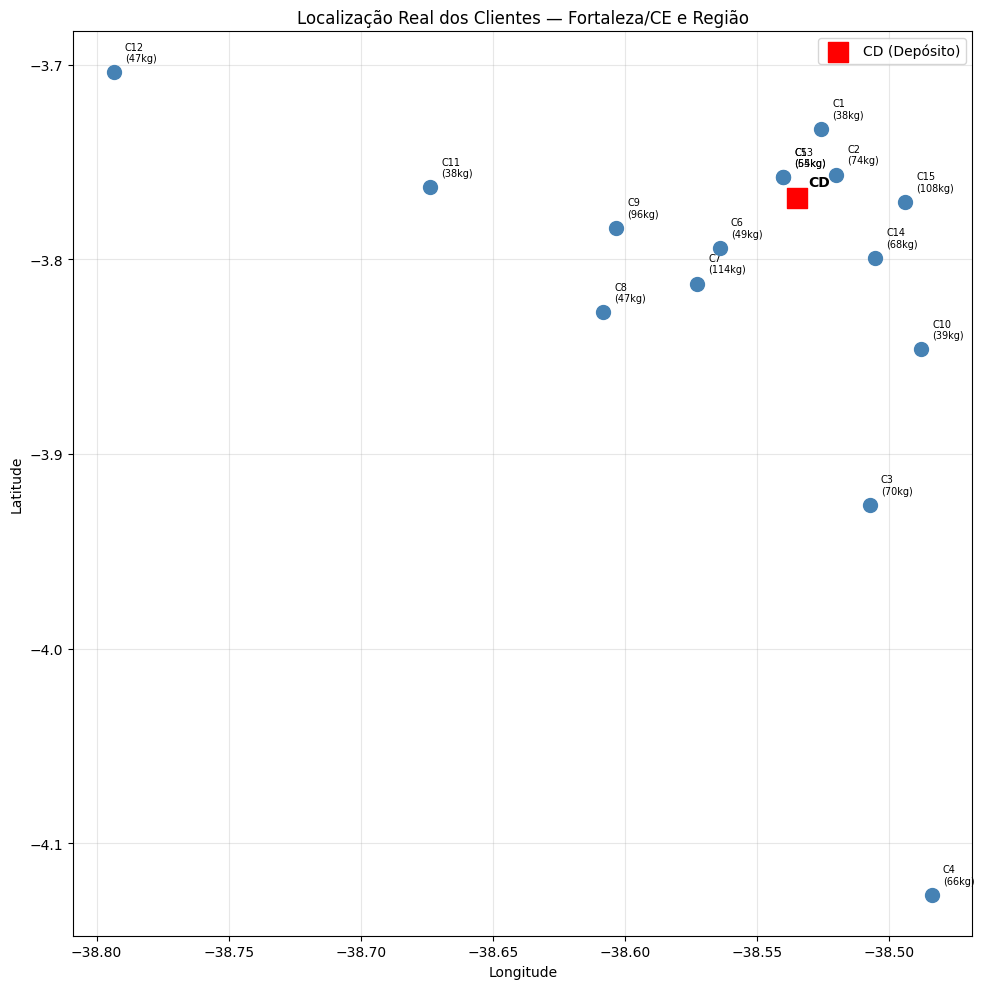

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

# CD (depósito)
lat_cd, lon_cd = coordenadas_gps[0]
ax.scatter(lon_cd, lat_cd, c='red', s=200, zorder=5, marker='s', label='CD (Depósito)')
ax.annotate('CD', (lon_cd, lat_cd), textcoords='offset points', xytext=(8, 8), fontsize=10, fontweight='bold')

# Clientes
for i in range(1, N):
    lat, lon = coordenadas_gps[i]
    ax.scatter(lon, lat, c='steelblue', s=100, zorder=5)
    ax.annotate(f'{nomes[i]}\n({demandas[i]}kg)', (lon, lat),
                textcoords='offset points', xytext=(8, 8), fontsize=7)

ax.set_title('Localização Real dos Clientes — Fortaleza/CE e Região')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Modelagem CVRP — Programação Inteira (PuLP)

In [6]:
clientes = list(range(1, N))
pontos = list(range(N))
veiculos = list(range(N_VEICULOS))

modelo = LpProblem('CVRP', LpMinimize)

x = LpVariable.dicts('x', (pontos, pontos, veiculos), cat='Binary')
u = LpVariable.dicts('u', (clientes, veiculos), lowBound=1, upBound=N_CLIENTES, cat='Continuous')

# FUNÇÃO OBJETIVO: minimizar distância total
modelo += lpSum(dist[i][j] * x[i][j][k] for i in pontos for j in pontos for k in veiculos if i != j)

# RESTRIÇÃO 1: cada cliente visitado exatamente 1 vez
for j in clientes:
    modelo += lpSum(x[i][j][k] for i in pontos for k in veiculos if i != j) == 1

# RESTRIÇÃO 2: cada veículo sai do CD no máximo 1 vez
for k in veiculos:
    modelo += lpSum(x[0][j][k] for j in clientes) <= 1

# RESTRIÇÃO 3: cada veículo retorna ao CD no máximo 1 vez
for k in veiculos:
    modelo += lpSum(x[j][0][k] for j in clientes) <= 1

# RESTRIÇÃO 4: conservação de fluxo
for k in veiculos:
    for j in clientes:
        modelo += lpSum(x[i][j][k] for i in pontos if i != j) == lpSum(x[j][i][k] for i in pontos if i != j)

# RESTRIÇÃO 5: capacidade do veículo
for k in veiculos:
    modelo += lpSum(demandas[j] * lpSum(x[i][j][k] for i in pontos if i != j) for j in clientes) <= CAPACIDADE

# RESTRIÇÃO 6: eliminação de sub-rotas (MTZ)
for k in veiculos:
    for i in clientes:
        for j in clientes:
            if i != j:
                modelo += u[i][k] - u[j][k] + N_CLIENTES * x[i][j][k] <= N_CLIENTES - 1

## 6. Resolução

In [7]:
modelo.solve(PULP_CBC_CMD(msg=1))

print(f'Status: {LpStatus[modelo.status]}')
dist_otimizada = round(value(modelo.objective), 2)
print(f'Distância total otimizada: {dist_otimizada} km')
print(f'Custo diário (km): R$ {round(dist_otimizada * CUSTO_POR_KM, 2)}')

Status: Optimal
Distância total otimizada: 191.51 km
Custo diário (km): R$ 670.28


## 7. Extração das Rotas

In [8]:
cores = ['green', 'purple', 'orange', 'cyan', 'magenta']

def extrair_rotas(x, pontos, clientes, veiculos):
    rotas = {}
    for k in veiculos:
        rota = [0]
        atual = 0
        while True:
            proximo = None
            for j in pontos:
                if j != atual and value(x[atual][j][k]) and value(x[atual][j][k]) > 0.5:
                    proximo = j
                    break
            if proximo is None or proximo == 0:
                rota.append(0)
                break
            rota.append(proximo)
            atual = proximo
        rotas[k] = rota
    return rotas

rotas = extrair_rotas(x, pontos, clientes, veiculos)

for k in veiculos:
    carga = sum(demandas[i] for i in rotas[k] if i != 0)
    rota_nomes = ' → '.join(nomes[i] for i in rotas[k])
    dist_rota = sum(dist[rotas[k][i]][rotas[k][i+1]] for i in range(len(rotas[k])-1))
    custo_rota = round(dist_rota * CUSTO_POR_KM, 2)
    print(f'Veículo {k+1}: {rota_nomes}')
    print(f'  Carga: {carga}/{CAPACIDADE} kg | Distância: {round(dist_rota, 2)} km | Custo: R$ {custo_rota}\n')

Veículo 1: CD (Depósito) → C6 → C7 → C8 → C11 → C12 → C9 → C1 → C13 → CD (Depósito)
  Carga: 494/500 kg | Distância: 91.17 km | Custo: R$ 319.1

Veículo 2: CD (Depósito) → C4 → C3 → C10 → C14 → C15 → C2 → C5 → CD (Depósito)
  Carga: 479/500 kg | Distância: 100.34 km | Custo: R$ 351.19



## 8. Visualização das Rotas Otimizadas

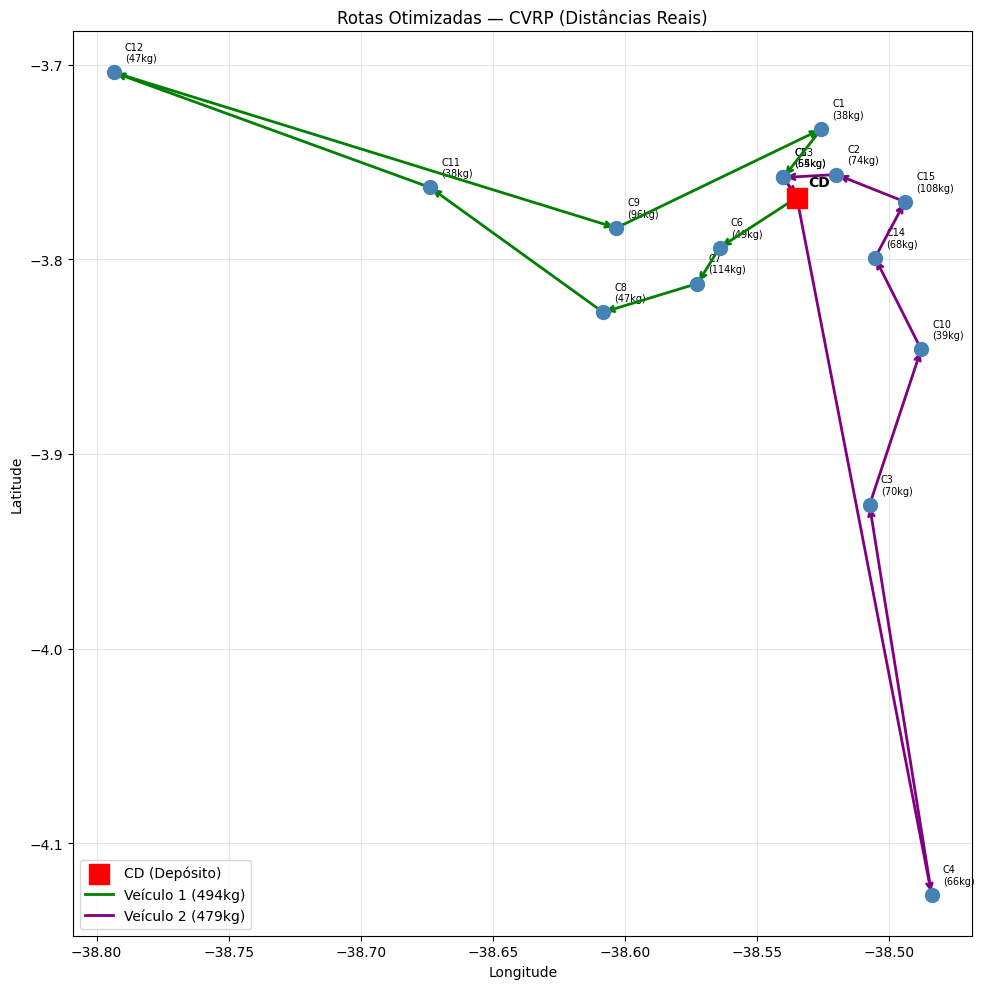

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# CD
lat_cd, lon_cd = coordenadas_gps[0]
ax.scatter(lon_cd, lat_cd, c='red', s=200, zorder=5, marker='s', label='CD (Depósito)')
ax.annotate('CD', (lon_cd, lat_cd), textcoords='offset points', xytext=(8, 8), fontsize=10, fontweight='bold')

# Clientes
for i in range(1, N):
    lat, lon = coordenadas_gps[i]
    ax.scatter(lon, lat, c='steelblue', s=100, zorder=5)
    ax.annotate(f'{nomes[i]}\n({demandas[i]}kg)', (lon, lat),
                textcoords='offset points', xytext=(8, 8), fontsize=7)

# Rotas
for k in veiculos:
    rota = rotas[k]
    cor = cores[k % len(cores)]
    for idx in range(len(rota) - 1):
        i, j = rota[idx], rota[idx + 1]
        lat_i, lon_i = coordenadas_gps[i]
        lat_j, lon_j = coordenadas_gps[j]
        ax.annotate('', xy=(lon_j, lat_j), xytext=(lon_i, lat_i),
                     arrowprops=dict(arrowstyle='->', color=cor, lw=2))
    carga = sum(demandas[i] for i in rota if i != 0)
    ax.plot([], [], color=cor, lw=2, label=f'Veículo {k+1} ({carga}kg)')

ax.set_title('Rotas Otimizadas — CVRP (Distâncias Reais)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Comparação: Rota Manual vs Otimizada

In [10]:
def rota_vizinho_mais_proximo(clientes_disponiveis, capacidade, demandas_local, dist_local):
    """
    Constrói uma rota usando o método do vizinho mais próximo.
    O motorista sempre vai para o cliente mais próximo que cabe no veículo.
    Retorna a rota (lista de IDs começando e terminando em 0).
    """
    rota = [0]  # começa no CD
    carga_atual = 0
    restantes = list(clientes_disponiveis)
    
    while restantes:
        atual = rota[-1]
        # Filtrar clientes que cabem no veículo
        viaveis = [c for c in restantes if carga_atual + demandas_local[c] <= capacidade]
        if not viaveis:
            break
        # Escolher o mais próximo
        mais_proximo = min(viaveis, key=lambda c: dist_local[atual][c])
        rota.append(mais_proximo)
        carga_atual += demandas_local[mais_proximo]
        restantes.remove(mais_proximo)
    
    rota.append(0)  # volta ao CD
    return rota, restantes  # retorna rota e clientes não atendidos


def gerar_rotas_manuais(n_veiculos, clientes_lista, capacidade, demandas_local, dist_local):
    """
    Gera rotas manuais para N veículos usando vizinho mais próximo.
    Cada veículo pega os clientes restantes do anterior.
    """
    rotas_manuais = {}
    restantes = list(clientes_lista)
    
    for k in range(n_veiculos):
        rota, restantes = rota_vizinho_mais_proximo(restantes, capacidade, demandas_local, dist_local)
        rotas_manuais[k] = rota
    
    return rotas_manuais

 
# Gerar rotas manuais realistas
rota_manual = gerar_rotas_manuais(N_VEICULOS, clientes, CAPACIDADE, demandas, dist)

 
def calcular_distancia_rota(rota):
    return sum(dist[rota[i]][rota[i+1]] for i in range(len(rota)-1))

dist_manual = sum(calcular_distancia_rota(rota_manual[k]) for k in veiculos)
custo_manual_dia = round(dist_manual * CUSTO_POR_KM, 2)
custo_otimizado_dia = round(dist_otimizada * CUSTO_POR_KM, 2)
economia_dia = round(custo_manual_dia - custo_otimizado_dia, 2)
economia_pct = round((1 - dist_otimizada / dist_manual) * 100, 1)
economia_mes = round(economia_dia * DIAS_UTEIS_MES, 2)
economia_ano = round(economia_dia * DIAS_UTEIS_MES * 12, 2)

# Custos totais mensais (km + salários)
salarios_2v = N_VEICULOS * SALARIO_MOTORISTA
custo_total_manual_mes = round(custo_manual_dia * DIAS_UTEIS_MES + salarios_2v, 2)
custo_total_otimizado_mes = round(custo_otimizado_dia * DIAS_UTEIS_MES + salarios_2v, 2)

print('=' * 65)
print('COMPARAÇÃO: ROTA MANUAL vs OTIMIZADA')
print('=' * 65)
for k in veiculos:
    print(f'\nRota Manual Veículo {k+1}: {" → ".join(nomes[i] for i in rota_manual[k])}')
    d = round(calcular_distancia_rota(rota_manual[k]), 2)
    print(f'  Distância: {d} km | Custo: R$ {round(d * CUSTO_POR_KM, 2)}')
for k in veiculos:
    print(f'\nRota Otimizada Veículo {k+1}: {" → ".join(nomes[i] for i in rotas[k])}')
    d = round(calcular_distancia_rota(rotas[k]), 2)
    print(f'  Distância: {d} km | Custo: R$ {round(d * CUSTO_POR_KM, 2)}')
print(f'\n{"─" * 65}')
print(f'Distância total MANUAL:    {round(dist_manual, 2)} km → R$ {custo_manual_dia}/dia')
print(f'Distância total OTIMIZADA: {dist_otimizada} km → R$ {custo_otimizado_dia}/dia')
print(f'Economia por viagem: R$ {economia_dia} ({economia_pct}%)')
print(f'Economia mensal (km): R$ {economia_mes}')
print(f'Economia anual (km): R$ {economia_ano}')
print(f'\nCusto mensal total (manual):    R$ {custo_total_manual_mes} ({N_VEICULOS} motoristas × R$ {SALARIO_MOTORISTA} + km)')
print(f'Custo mensal total (otimizado): R$ {custo_total_otimizado_mes} ({N_VEICULOS} motoristas × R$ {SALARIO_MOTORISTA} + km)')
print('=' * 65)

COMPARAÇÃO: ROTA MANUAL vs OTIMIZADA

Rota Manual Veículo 1: CD (Depósito) → C5 → C13 → C1 → C2 → C15 → C14 → C6 → C10 → CD (Depósito)
  Distância: 57.77 km | Custo: R$ 202.2

Rota Manual Veículo 2: CD (Depósito) → C7 → C9 → C8 → C11 → C12 → C3 → C4 → CD (Depósito)
  Distância: 173.22 km | Custo: R$ 606.27

Rota Otimizada Veículo 1: CD (Depósito) → C6 → C7 → C8 → C11 → C12 → C9 → C1 → C13 → CD (Depósito)
  Distância: 91.17 km | Custo: R$ 319.1

Rota Otimizada Veículo 2: CD (Depósito) → C4 → C3 → C10 → C14 → C15 → C2 → C5 → CD (Depósito)
  Distância: 100.34 km | Custo: R$ 351.19

─────────────────────────────────────────────────────────────────
Distância total MANUAL:    230.99 km → R$ 808.47/dia
Distância total OTIMIZADA: 191.51 km → R$ 670.28/dia
Economia por viagem: R$ 138.19 (17.1%)
Economia mensal (km): R$ 3040.18
Economia anual (km): R$ 36482.16

Custo mensal total (manual):    R$ 23786.34 (2 motoristas × R$ 3000.0 + km)
Custo mensal total (otimizado): R$ 20746.16 (2 motoristas × 

## 10. Análise de Sensibilidade

In [11]:
def resolver_cvrp(n_veiculos, coords_gps, dem, cap, nomes_pontos, matriz_dist):
    n = len(coords_gps)
    cli = list(range(1, n))
    pts = list(range(n))
    veics = list(range(n_veiculos))

    m = LpProblem(f'CVRP_{n_veiculos}v', LpMinimize)
    xv = LpVariable.dicts('x', (pts, pts, veics), cat='Binary')
    uv = LpVariable.dicts('u', (cli, veics), lowBound=1, upBound=len(cli), cat='Continuous')

    m += lpSum(matriz_dist[i][j] * xv[i][j][k] for i in pts for j in pts for k in veics if i != j)

    for j in cli:
        m += lpSum(xv[i][j][k] for i in pts for k in veics if i != j) == 1
    for k in veics:
        m += lpSum(xv[0][j][k] for j in cli) <= 1
        m += lpSum(xv[j][0][k] for j in cli) <= 1
    for k in veics:
        for j in cli:
            m += lpSum(xv[i][j][k] for i in pts if i != j) == lpSum(xv[j][i][k] for i in pts if i != j)
    for k in veics:
        m += lpSum(dem[j] * lpSum(xv[i][j][k] for i in pts if i != j) for j in cli) <= cap
    for k in veics:
        for i in cli:
            for j in cli:
                if i != j:
                    m += uv[i][k] - uv[j][k] + len(cli) * xv[i][j][k] <= len(cli) - 1

    m.solve(PULP_CBC_CMD(msg=0))
    rotas_r = extrair_rotas(xv, pts, cli, veics)
    return m, rotas_r

### Cenário A: 3 veículos em vez de 2

In [12]:
modelo_3v, rotas_3v = resolver_cvrp(3, coordenadas_gps, demandas, CAPACIDADE, nomes, dist)
dist_3v = round(value(modelo_3v.objective), 2)
custo_3v_dia = round(dist_3v * CUSTO_POR_KM, 2)
salarios_3v = 3 * SALARIO_MOTORISTA
custo_total_3v_mes = round(custo_3v_dia * DIAS_UTEIS_MES + salarios_3v, 2)
economia_km_3v_mes = round((custo_otimizado_dia - custo_3v_dia) * DIAS_UTEIS_MES, 2)
custo_extra_motorista = SALARIO_MOTORISTA
saldo_3v = round(economia_km_3v_mes - custo_extra_motorista, 2)

print('=' * 65)
print('CENÁRIO A: 3 VEÍCULOS')
print('=' * 65)
print(f'Distância com 2 veículos: {dist_otimizada} km → R$ {custo_otimizado_dia}/dia')
print(f'Distância com 3 veículos: {dist_3v} km → R$ {custo_3v_dia}/dia')
print(f'Redução de distância: {round((1 - dist_3v / dist_otimizada) * 100, 1)}%')
print(f'\nEconomia em km/mês: R$ {economia_km_3v_mes}')
print(f'Custo extra 3º motorista: R$ {custo_extra_motorista}/mês')
print(f'Saldo mensal: R$ {saldo_3v}')
print(f'\nCusto mensal total (2 veículos): R$ {custo_total_otimizado_mes}')
print(f'Custo mensal total (3 veículos): R$ {custo_total_3v_mes}')
if saldo_3v > 0:
    print(f'\n✅ COMPENSA adicionar o 3º veículo (economia líquida: R$ {saldo_3v}/mês)')
else:
    print(f'\n❌ NÃO COMPENSA adicionar o 3º veículo (prejuízo: R$ {abs(saldo_3v)}/mês)')
print('=' * 65)

CENÁRIO A: 3 VEÍCULOS
Distância com 2 veículos: 191.51 km → R$ 670.28/dia
Distância com 3 veículos: 188.88 km → R$ 661.08/dia
Redução de distância: 1.4%

Economia em km/mês: R$ 202.4
Custo extra 3º motorista: R$ 3000.0/mês
Saldo mensal: R$ -2797.6

Custo mensal total (2 veículos): R$ 20746.16
Custo mensal total (3 veículos): R$ 23543.76

❌ NÃO COMPENSA adicionar o 3º veículo (prejuízo: R$ 2797.6/mês)


### Cenário B: +1 cliente novo

In [13]:
# Adicionar um cliente fictício próximo à região
coord_novo = (-3.85, -38.55)
demanda_novo = random.randint(40, 100)
coords_16 = coordenadas_gps + [coord_novo]
demandas_16 = demandas + [demanda_novo]
nomes_16 = nomes + ['C16']

# Recalcular matriz de distâncias com o novo ponto
try:
    dist_16 = obter_matriz_distancias_osrm(coords_16)
except:
    def distancia_euclidiana_km(p1, p2):
        dlat = (p1[0] - p2[0]) * 111
        dlon = (p1[1] - p2[1]) * 111 * np.cos(np.radians((p1[0] + p2[0]) / 2))
        return round(np.sqrt(dlat**2 + dlon**2), 2)
    n16 = len(coords_16)
    dist_16 = [[distancia_euclidiana_km(coords_16[i], coords_16[j]) for j in range(n16)] for i in range(n16)]

print(f'Novo cliente C16: coordenadas {coord_novo}, demanda {demanda_novo}kg')

modelo_16c, rotas_16c = resolver_cvrp(2, coords_16, demandas_16, CAPACIDADE, nomes_16, dist_16)
dist_16c = round(value(modelo_16c.objective), 2)

print(f'\nDistância com 15 clientes: {dist_otimizada} km')
print(f'Distância com 16 clientes: {dist_16c} km')
print(f'Aumento: {round((dist_16c / dist_otimizada - 1) * 100, 1)}%')

Consultando API OSRM para distâncias reais por estrada...
✅ Matriz 17x17 de distâncias reais obtida com sucesso!
Novo cliente C16: coordenadas (-3.85, -38.55), demanda 78kg

Distância com 15 clientes: 191.51 km
Distância com 16 clientes: 147.06 km
Aumento: -23.2%


### Cenário C: apenas 1 veículo

In [14]:
demanda_total = sum(demandas)
print(f'Demanda total: {demanda_total}kg | Capacidade 1 veículo: {CAPACIDADE}kg')

if demanda_total > CAPACIDADE:
    print(f'\n⚠️ INVIÁVEL! Demanda total ({demanda_total}kg) excede capacidade de 1 veículo ({CAPACIDADE}kg)')
    print('Isso demonstra que a frota de 2 veículos é necessária.')
else:
    modelo_1v, rotas_1v = resolver_cvrp(1, coordenadas_gps, demandas, CAPACIDADE, nomes, dist)
    dist_1v = round(value(modelo_1v.objective), 2)
    custo_1v_dia = round(dist_1v * CUSTO_POR_KM, 2)
    salarios_1v = 1 * SALARIO_MOTORISTA
    custo_total_1v_mes = round(custo_1v_dia * DIAS_UTEIS_MES + salarios_1v, 2)
    print(f'\nDistância com 2 veículos: {dist_otimizada} km')
    print(f'Distância com 1 veículo:  {dist_1v} km')
    print(f'Aumento de distância: {round((dist_1v / dist_otimizada - 1) * 100, 1)}%')
    print(f'\nCusto mensal total (2 veículos): R$ {custo_total_otimizado_mes}')
    print(f'Custo mensal total (1 veículo):  R$ {custo_total_1v_mes}')

Demanda total: 973kg | Capacidade 1 veículo: 500kg

⚠️ INVIÁVEL! Demanda total (973kg) excede capacidade de 1 veículo (500kg)
Isso demonstra que a frota de 2 veículos é necessária.


## 11. Resumo dos Resultados

In [15]:
print('=' * 70)
print('RESUMO FINAL DOS RESULTADOS')
print('=' * 70)
print(f'\n📊 Parâmetros de Custo:')
print(f'   Custo por km: R$ {CUSTO_POR_KM}')
print(f'   Salário por motorista: R$ {SALARIO_MOTORISTA}/mês')
print(f'   Dias úteis/mês: {DIAS_UTEIS_MES}')
print(f'\n📊 Cenário Base (2 veículos, 15 clientes):')
print(f'   Distância otimizada: {dist_otimizada} km/dia')
print(f'   Distância manual:    {round(dist_manual, 2)} km/dia')
print(f'   Economia em distância: {economia_pct}%')
print(f'   Economia diária (km): R$ {economia_dia}')
print(f'   Economia mensal (km): R$ {economia_mes}')
print(f'   Economia anual (km):  R$ {economia_ano}')
print(f'   Custo mensal total (otimizado): R$ {custo_total_otimizado_mes}')
print(f'\n📊 Cenário A — 3 veículos:')
print(f'   Distância: {dist_3v} km (redução de {round((1 - dist_3v/dist_otimizada)*100,1)}%)')
print(f'   Economia km/mês: R$ {economia_km_3v_mes}')
print(f'   Custo extra motorista: R$ {custo_extra_motorista}/mês')
print(f'   Saldo: R$ {saldo_3v}/mês ({"COMPENSA" if saldo_3v > 0 else "NÃO COMPENSA"})')
print(f'   Custo mensal total: R$ {custo_total_3v_mes}')
print(f'\n📊 Cenário B — +1 cliente:')
print(f'   Distância: {dist_16c} km (aumento de {round((dist_16c/dist_otimizada-1)*100,1)}%)')
print(f'\n📊 Cenário C — 1 veículo:')
demanda_total = sum(demandas)
if demanda_total > CAPACIDADE:
    print(f'   INVIÁVEL — demanda ({demanda_total}kg) > capacidade ({CAPACIDADE}kg)')
else:
    print(f'   Distância: {dist_1v} km (aumento de {round((dist_1v/dist_otimizada-1)*100,1)}%)')
    print(f'   Custo mensal total: R$ {custo_total_1v_mes}')
print('=' * 70)

RESUMO FINAL DOS RESULTADOS

📊 Parâmetros de Custo:
   Custo por km: R$ 3.5
   Salário por motorista: R$ 3000.0/mês
   Dias úteis/mês: 22

📊 Cenário Base (2 veículos, 15 clientes):
   Distância otimizada: 191.51 km/dia
   Distância manual:    230.99 km/dia
   Economia em distância: 17.1%
   Economia diária (km): R$ 138.19
   Economia mensal (km): R$ 3040.18
   Economia anual (km):  R$ 36482.16
   Custo mensal total (otimizado): R$ 20746.16

📊 Cenário A — 3 veículos:
   Distância: 188.88 km (redução de 1.4%)
   Economia km/mês: R$ 202.4
   Custo extra motorista: R$ 3000.0/mês
   Saldo: R$ -2797.6/mês (NÃO COMPENSA)
   Custo mensal total: R$ 23543.76

📊 Cenário B — +1 cliente:
   Distância: 147.06 km (aumento de -23.2%)

📊 Cenário C — 1 veículo:
   INVIÁVEL — demanda (973kg) > capacidade (500kg)


## 12. Conclusões

**Insights descobertos:**

1. **Decisão subótima:** A rota manual gera distância significativamente maior
   que a rota otimizada, demonstrando o valor da otimização matemática.

2. **Trade-off revelado:** Adicionar um 3º veículo reduz a distância, mas o ganho
   precisa ser comparado com o custo operacional adicional (motorista R$ 3.000/mês).

3. **Gargalo escondido:** A capacidade dos veículos é a restrição que mais impacta
   a distribuição dos clientes entre as rotas.

4. **Viabilidade:** Com apenas 1 veículo, dependendo da demanda total, o cenário
   pode ser inviável — reforçando a necessidade da frota mínima de 2 veículos.

5. **Impacto financeiro:** A otimização de rotas gera economia real e mensurável,
   justificando o investimento em ferramentas de otimização.

**Limitações do modelo:**
- Distâncias calculadas via OSRM (rodoviárias), mas sem considerar trânsito em tempo real
- Sem janelas de horário para entregas
- Custo por km fixo (não considera variações de combustível, pedágios, etc.)

**Próximos passos:**
- Incluir janelas de tempo (VRPTW)
- Integrar dados de trânsito em tempo real
- Testar com frota heterogênea (veículos de diferentes capacidades)
- Avaliar heurísticas (Genetic Algorithm, Simulated Annealing) para instâncias maiores

## 13. Análise de Tempo de Deslocamento — Velocidade Média de Fortaleza/CE

In [16]:
# Parâmetros de velocidade média em Fortaleza/CE
cenarios_velocidade = {
    'Horário de Pico (7h-9h / 17h-19h)': {'vel_km_h': 20, 'descricao': 'Trânsito intenso'},
    'Fora do Pico (10h-16h)':              {'vel_km_h': 35, 'descricao': 'Trânsito moderado'},
    'Média Ponderada do Dia':              {'vel_km_h': 25, 'descricao': 'Cenário realista'},
}

# Custo hora do motorista
HORAS_DIA = 8
CUSTO_HORA_MOTORISTA = round(SALARIO_MOTORISTA / DIAS_UTEIS_MES / HORAS_DIA, 2)

print('=' * 75)
print('ANÁLISE DE TEMPO DE DESLOCAMENTO — FORTALEZA/CE')
print('=' * 75)
print(f'\nCusto hora do motorista: R$ {SALARIO_MOTORISTA} / {DIAS_UTEIS_MES} dias / {HORAS_DIA}h = R$ {CUSTO_HORA_MOTORISTA}/hora')
print(f'\nDistância rota MANUAL:    {round(dist_manual, 2)} km')
print(f'Distância rota OTIMIZADA: {dist_otimizada} km')

# Armazenar resultados para uso posterior
resultados_tempo = {}

for cenario, dados in cenarios_velocidade.items():
    vel = dados['vel_km_h']
    tempo_km_min = round(60 / vel, 2)  # minutos por km
    
    # Tempo total de cada cenário
    tempo_manual_min = round(dist_manual * tempo_km_min, 1)
    tempo_otimizado_min = round(dist_otimizada * tempo_km_min, 1)
    economia_tempo_min = round(tempo_manual_min - tempo_otimizado_min, 1)
    
    tempo_manual_h = round(tempo_manual_min / 60, 2)
    tempo_otimizado_h = round(tempo_otimizado_min / 60, 2)
    economia_tempo_h = round(economia_tempo_min / 60, 2)
    
    # Custo do tempo (motorista parado no trânsito = custo)
    custo_tempo_manual = round(tempo_manual_h * CUSTO_HORA_MOTORISTA * N_VEICULOS, 2)
    custo_tempo_otimizado = round(tempo_otimizado_h * CUSTO_HORA_MOTORISTA * N_VEICULOS, 2)
    economia_custo_tempo = round(custo_tempo_manual - custo_tempo_otimizado, 2)
    
    resultados_tempo[cenario] = {
        'vel': vel,
        'tempo_km_min': tempo_km_min,
        'tempo_manual_h': tempo_manual_h,
        'tempo_otimizado_h': tempo_otimizado_h,
        'economia_tempo_h': economia_tempo_h,
        'economia_tempo_min': economia_tempo_min,
        'custo_tempo_manual': custo_tempo_manual,
        'custo_tempo_otimizado': custo_tempo_otimizado,
        'economia_custo_tempo': economia_custo_tempo,
    }
    
    print(f'\n{"─" * 75}')
    print(f'📊 {cenario} ({dados["descricao"]})')
    print(f'   Velocidade média: {vel} km/h ({tempo_km_min} min/km)')
    print(f'   Tempo rota MANUAL:    {tempo_manual_h}h ({tempo_manual_min} min) — {N_VEICULOS} veículos')
    print(f'   Tempo rota OTIMIZADA: {tempo_otimizado_h}h ({tempo_otimizado_min} min) — {N_VEICULOS} veículos')
    print(f'   Economia de tempo: {economia_tempo_h}h ({economia_tempo_min} min) por veículo')
    print(f'   Custo tempo MANUAL (2 motoristas):    R$ {custo_tempo_manual}/dia')
    print(f'   Custo tempo OTIMIZADO (2 motoristas): R$ {custo_tempo_otimizado}/dia')
    print(f'   Economia em custo de tempo: R$ {economia_custo_tempo}/dia')

print(f'\n{"═" * 75}')

ANÁLISE DE TEMPO DE DESLOCAMENTO — FORTALEZA/CE

Custo hora do motorista: R$ 3000.0 / 22 dias / 8h = R$ 17.05/hora

Distância rota MANUAL:    230.99 km
Distância rota OTIMIZADA: 191.51 km

───────────────────────────────────────────────────────────────────────────
📊 Horário de Pico (7h-9h / 17h-19h) (Trânsito intenso)
   Velocidade média: 20 km/h (3.0 min/km)
   Tempo rota MANUAL:    11.55h (693.0 min) — 2 veículos
   Tempo rota OTIMIZADA: 9.57h (574.5 min) — 2 veículos
   Economia de tempo: 1.98h (118.5 min) por veículo
   Custo tempo MANUAL (2 motoristas):    R$ 393.86/dia
   Custo tempo OTIMIZADO (2 motoristas): R$ 326.34/dia
   Economia em custo de tempo: R$ 67.52/dia

───────────────────────────────────────────────────────────────────────────
📊 Fora do Pico (10h-16h) (Trânsito moderado)
   Velocidade média: 35 km/h (1.71 min/km)
   Tempo rota MANUAL:    6.58h (395.0 min) — 2 veículos
   Tempo rota OTIMIZADA: 5.46h (327.5 min) — 2 veículos
   Economia de tempo: 1.12h (67.5 min) por

## 14. Custo Total Combinado (Distância + Tempo)

In [17]:
print('=' * 75)
print('CUSTO TOTAL COMBINADO: DISTÂNCIA (R$/km) + TEMPO (R$/hora motorista)')
print('=' * 75)

# Cenário realista (média ponderada)
cenario_realista = 'Média Ponderada do Dia'
dados_r = resultados_tempo[cenario_realista]

print(f'\nCenário: {cenario_realista} ({dados_r["vel"]} km/h)')
print(f'Custo por km: R$ {CUSTO_POR_KM}')
print(f'Custo hora motorista: R$ {CUSTO_HORA_MOTORISTA}')

# Custo diário combinado = custo km + custo tempo em trânsito
custo_km_manual_dia = round(dist_manual * CUSTO_POR_KM, 2)
custo_km_otimizado_dia = round(dist_otimizada * CUSTO_POR_KM, 2)

custo_combinado_manual_dia = round(custo_km_manual_dia + dados_r['custo_tempo_manual'], 2)
custo_combinado_otimizado_dia = round(custo_km_otimizado_dia + dados_r['custo_tempo_otimizado'], 2)
economia_combinada_dia = round(custo_combinado_manual_dia - custo_combinado_otimizado_dia, 2)

# Mensal
custo_combinado_manual_mes = round(custo_combinado_manual_dia * DIAS_UTEIS_MES + N_VEICULOS * SALARIO_MOTORISTA, 2)
custo_combinado_otimizado_mes = round(custo_combinado_otimizado_dia * DIAS_UTEIS_MES + N_VEICULOS * SALARIO_MOTORISTA, 2)
economia_combinada_mes = round(economia_combinada_dia * DIAS_UTEIS_MES, 2)
economia_combinada_ano = round(economia_combinada_mes * 12, 2)

print(f'\n{"─" * 75}')
print(f'ROTA MANUAL:')
print(f'  Custo km/dia:     R$ {custo_km_manual_dia}')
print(f'  Custo tempo/dia:  R$ {dados_r["custo_tempo_manual"]}')
print(f'  Total diário:     R$ {custo_combinado_manual_dia}')
print(f'  Total mensal:     R$ {custo_combinado_manual_mes} (inclui salários)')

print(f'\nROTA OTIMIZADA:')
print(f'  Custo km/dia:     R$ {custo_km_otimizado_dia}')
print(f'  Custo tempo/dia:  R$ {dados_r["custo_tempo_otimizado"]}')
print(f'  Total diário:     R$ {custo_combinado_otimizado_dia}')
print(f'  Total mensal:     R$ {custo_combinado_otimizado_mes} (inclui salários)')

print(f'\n{"─" * 75}')
print(f'💰 ECONOMIA COMBINADA (distância + tempo):')
print(f'  Por dia:  R$ {economia_combinada_dia}')
print(f'  Por mês:  R$ {economia_combinada_mes}')
print(f'  Por ano:  R$ {economia_combinada_ano}')
print(f'\n{"═" * 75}')

CUSTO TOTAL COMBINADO: DISTÂNCIA (R$/km) + TEMPO (R$/hora motorista)

Cenário: Média Ponderada do Dia (25 km/h)
Custo por km: R$ 3.5
Custo hora motorista: R$ 17.05

───────────────────────────────────────────────────────────────────────────
ROTA MANUAL:
  Custo km/dia:     R$ 808.47
  Custo tempo/dia:  R$ 315.08
  Total diário:     R$ 1123.55
  Total mensal:     R$ 30718.1 (inclui salários)

ROTA OTIMIZADA:
  Custo km/dia:     R$ 670.28
  Custo tempo/dia:  R$ 261.21
  Total diário:     R$ 931.49
  Total mensal:     R$ 26492.78 (inclui salários)

───────────────────────────────────────────────────────────────────────────
💰 ECONOMIA COMBINADA (distância + tempo):
  Por dia:  R$ 192.06
  Por mês:  R$ 4225.32
  Por ano:  R$ 50703.84

═══════════════════════════════════════════════════════════════════════════


## 15. Comparação por Cenário de Trânsito

In [18]:
print('=' * 75)
print('COMPARAÇÃO: IMPACTO DO HORÁRIO DE SAÍDA NA ECONOMIA')
print('=' * 75)
print(f'\n{"Cenário":<40} {"Economia/dia":>15} {"Economia/mês":>15} {"Economia/ano":>15}')
print(f'{"─" * 85}')

for cenario, dados_r in resultados_tempo.items():
    custo_comb_manual = round(dist_manual * CUSTO_POR_KM + dados_r['custo_tempo_manual'], 2)
    custo_comb_otim = round(dist_otimizada * CUSTO_POR_KM + dados_r['custo_tempo_otimizado'], 2)
    eco_dia = round(custo_comb_manual - custo_comb_otim, 2)
    eco_mes = round(eco_dia * DIAS_UTEIS_MES, 2)
    eco_ano = round(eco_mes * 12, 2)
    
    print(f'{cenario:<40} R$ {eco_dia:>10,.2f} R$ {eco_mes:>10,.2f} R$ {eco_ano:>10,.2f}')

print(f'\n{"═" * 75}')
print(f'\n💡 Insight: No horário de pico, a economia é MAIOR porque o tempo')
print(f'   desperdiçado no trânsito com rotas manuais custa mais caro.')
print(f'   Otimizar rotas é ainda mais valioso quando o trânsito é intenso.')

COMPARAÇÃO: IMPACTO DO HORÁRIO DE SAÍDA NA ECONOMIA

Cenário                                     Economia/dia    Economia/mês    Economia/ano
─────────────────────────────────────────────────────────────────────────────────────
Horário de Pico (7h-9h / 17h-19h)        R$     205.71 R$   4,525.62 R$  54,307.44
Fora do Pico (10h-16h)                   R$     176.38 R$   3,880.36 R$  46,564.32
Média Ponderada do Dia                   R$     192.06 R$   4,225.32 R$  50,703.84

═══════════════════════════════════════════════════════════════════════════

💡 Insight: No horário de pico, a economia é MAIOR porque o tempo
   desperdiçado no trânsito com rotas manuais custa mais caro.
   Otimizar rotas é ainda mais valioso quando o trânsito é intenso.


## 16. Gráfico: Economia por Cenário de Trânsito

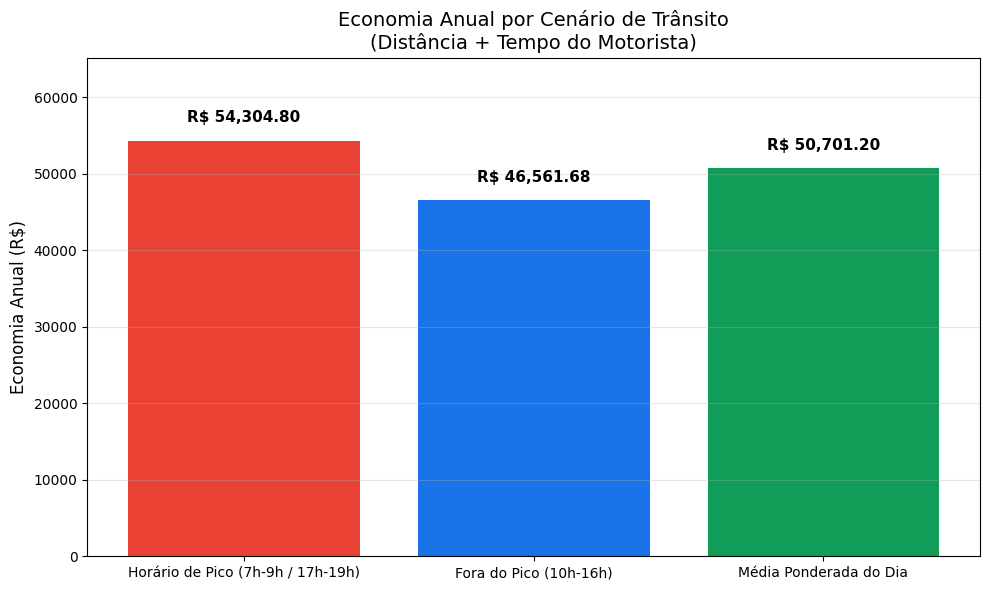

In [19]:
cenarios_nomes = list(resultados_tempo.keys())
economias_ano = []

for cenario in cenarios_nomes:
    dados_r = resultados_tempo[cenario]
    custo_comb_manual = dist_manual * CUSTO_POR_KM + dados_r['custo_tempo_manual']
    custo_comb_otim = dist_otimizada * CUSTO_POR_KM + dados_r['custo_tempo_otimizado']
    eco_ano = round((custo_comb_manual - custo_comb_otim) * DIAS_UTEIS_MES * 12, 2)
    economias_ano.append(eco_ano)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(cenarios_nomes, economias_ano, color=['#ea4335', '#1a73e8', '#0f9d58'])

for bar, val in zip(bars, economias_ano):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'R$ {val:,.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Economia Anual por Cenário de Trânsito\n(Distância + Tempo do Motorista)', fontsize=14)
ax.set_ylabel('Economia Anual (R$)', fontsize=12)
ax.set_ylim(0, max(economias_ano) * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Análise de Ponto de Equilíbrio: 2 vs 3 Veículos por Demanda

In [20]:
# Função para gerar demandas proporcionais a um alvo
def gerar_demandas_alvo(demandas_base, alvo_total):
    """Escala as demandas base proporcionalmente para atingir o alvo total."""
    base_sem_cd = demandas_base[1:]  # remove CD (demanda 0)
    soma_base = sum(base_sem_cd)
    if soma_base == 0:
        return demandas_base
    fator = alvo_total / soma_base
    novas = [max(20, int(d * fator)) for d in base_sem_cd]
    # Ajuste fino para bater o alvo
    diff = alvo_total - sum(novas)
    if diff > 0:
        for i in range(diff):
            idx = i % len(novas)
            novas[idx] += 1
    elif diff < 0:
        for i in range(-diff):
            idx_max = novas.index(max(novas))
            novas[idx_max] -= 1
    return [0] + novas


def resolver_e_custo_mensal(n_veiculos, demandas_teste, cap, matriz_dist, coords_gps, nomes_pts):
    """Resolve o CVRP e retorna o custo mensal total (km + salários). Retorna None se inviável."""
    n = len(coords_gps)
    cli = list(range(1, n))
    pts = list(range(n))
    veics = list(range(n_veiculos))

    m = LpProblem(f'CVRP_{n_veiculos}v_{sum(demandas_teste)}kg', LpMinimize)
    xv = LpVariable.dicts('x', (pts, pts, veics), cat='Binary')
    uv = LpVariable.dicts('u', (cli, veics), lowBound=1, upBound=len(cli), cat='Continuous')

    m += lpSum(matriz_dist[i][j] * xv[i][j][k] for i in pts for j in pts for k in veics if i != j)

    for j in cli:
        m += lpSum(xv[i][j][k] for i in pts for k in veics if i != j) == 1
    for k in veics:
        m += lpSum(xv[0][j][k] for j in cli) <= 1
        m += lpSum(xv[j][0][k] for j in cli) <= 1
    for k in veics:
        for j in cli:
            m += lpSum(xv[i][j][k] for i in pts if i != j) == lpSum(xv[j][i][k] for i in pts if i != j)
    for k in veics:
        m += lpSum(demandas_teste[j] * lpSum(xv[i][j][k] for i in pts if i != j) for j in cli) <= cap
    for k in veics:
        for i in cli:
            for j in cli:
                if i != j:
                    m += uv[i][k] - uv[j][k] + len(cli) * xv[i][j][k] <= len(cli) - 1

    m.solve(PULP_CBC_CMD(msg=0, timeLimit=600))
    
    if LpStatus[m.status] != 'Optimal':
        return None, None  # Inviável
    
    dist_total = round(value(m.objective), 2)
    custo_km_mes = round(dist_total * CUSTO_POR_KM * DIAS_UTEIS_MES, 2)
    custo_salarios = n_veiculos * SALARIO_MOTORISTA
    custo_total_mes = round(custo_km_mes + custo_salarios, 2)
    
    return dist_total, custo_total_mes

In [ ]:
# Testar diferentes níveis de demanda
demandas_teste = [950, 973, 1050, 1100, 1150, 1200, 1300, 1400, 1500]

resultados_2v = []
resultados_3v = []

print('=' * 85)
print('ANÁLISE DE PONTO DE EQUILÍBRIO: 2 vs 3 VEÍCULOS POR DEMANDA')
print('=' * 85)
print(f'\n{"Demanda (kg)":<15} {"2V Dist (km)":>15} {"2V Custo/mês":>15} {"3V Dist (km)":>15} {"3V Custo/mês":>15} {"Melhor":>10}')
print(f'{"─" * 85}')

for alvo in demandas_teste:
    dem_teste = gerar_demandas_alvo(demandas, alvo)
    
    # 2 veículos
    if alvo <= N_VEICULOS * CAPACIDADE:
        dist_2v, custo_2v = resolver_e_custo_mensal(2, dem_teste, CAPACIDADE, dist, coordenadas_gps, nomes)
    else:
        dist_2v, custo_2v = None, None
    
    # 3 veículos
    if alvo <= 3 * CAPACIDADE:
        dist_3v, custo_3v = resolver_e_custo_mensal(3, dem_teste, CAPACIDADE, dist, coordenadas_gps, nomes)
    else:
        dist_3v, custo_3v = None, None
    
    resultados_2v.append((alvo, dist_2v, custo_2v))
    resultados_3v.append((alvo, dist_3v, custo_3v))
    
    str_2v_dist = f'{dist_2v}' if dist_2v else 'INVIÁVEL'
    str_2v_custo = f'R$ {custo_2v:,.2f}' if custo_2v else 'INVIÁVEL'
    str_3v_dist = f'{dist_3v}' if dist_3v else 'INVIÁVEL'
    str_3v_custo = f'R$ {custo_3v:,.2f}' if custo_3v else 'INVIÁVEL'
    
    if custo_2v and custo_3v:
        melhor = '2V ✅' if custo_2v <= custo_3v else '3V ✅'
    elif custo_2v:
        melhor = '2V ✅'
    elif custo_3v:
        melhor = '3V ✅'
    else:
        melhor = '—'
    
    print(f'{alvo:<15} {str_2v_dist:>15} {str_2v_custo:>15} {str_3v_dist:>15} {str_3v_custo:>15} {melhor:>10}')

print(f'\n{"═" * 85}')

ANÁLISE DE PONTO DE EQUILÍBRIO: 2 vs 3 VEÍCULOS POR DEMANDA

Demanda (kg)       2V Dist (km)    2V Custo/mês    3V Dist (km)    3V Custo/mês     Melhor
─────────────────────────────────────────────────────────────────────────────────────
950                      186.72    R$ 20,377.44          186.72    R$ 23,377.44       2V ✅
973                      191.51    R$ 20,746.27          188.88    R$ 23,543.76       2V ✅
1050                   INVIÁVEL        INVIÁVEL          191.57    R$ 23,750.89       3V ✅


## 18. Gráfico: Ponto de Equilíbrio 2 vs 3 Veículos

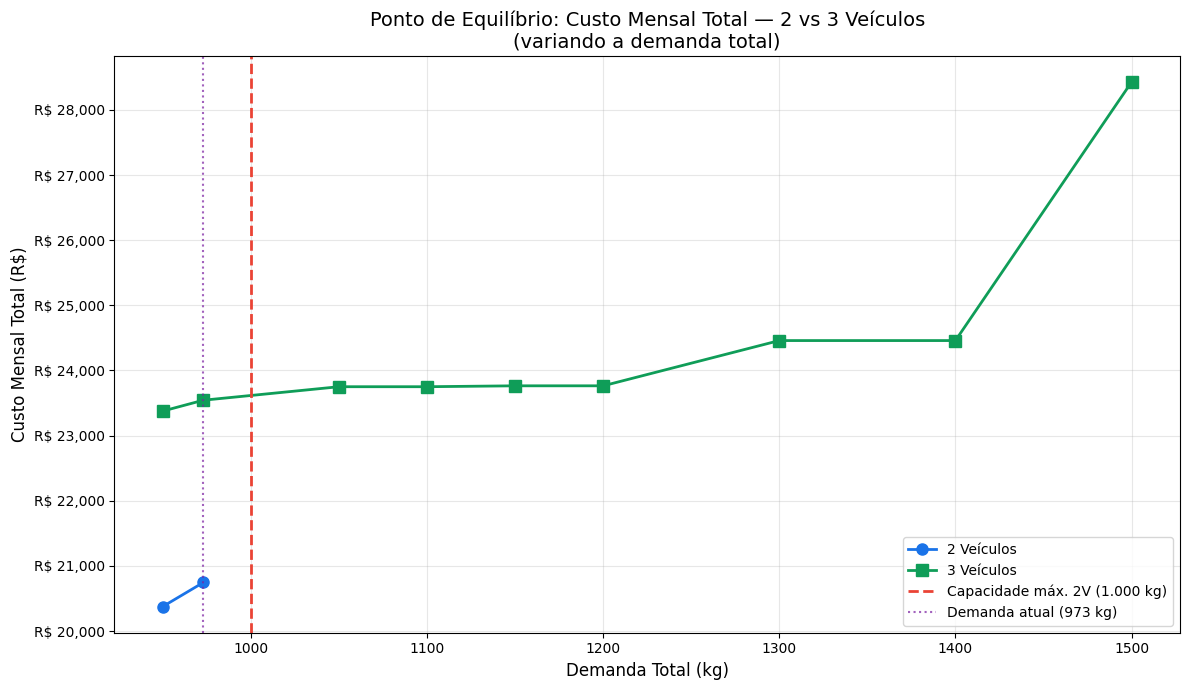

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Dados para o gráfico
demandas_plot = [r[0] for r in resultados_2v]
custos_2v = [r[2] if r[2] else None for r in resultados_2v]
custos_3v = [r[2] if r[2] else None for r in resultados_3v]

# Filtrar pontos válidos para cada série
x_2v = [d for d, c in zip(demandas_plot, custos_2v) if c is not None]
y_2v = [c for c in custos_2v if c is not None]

x_3v = [d for d, c in zip(demandas_plot, custos_3v) if c is not None]
y_3v = [c for c in custos_3v if c is not None]

ax.plot(x_2v, y_2v, 'o-', color='#1a73e8', linewidth=2, markersize=8, label='2 Veículos')
ax.plot(x_3v, y_3v, 's-', color='#0f9d58', linewidth=2, markersize=8, label='3 Veículos')

# Linha vertical na capacidade máxima de 2 veículos
ax.axvline(x=1000, color='#ea4335', linestyle='--', linewidth=2, label='Capacidade máx. 2V (1.000 kg)')

# Marcar o ponto atual
ax.axvline(x=973, color='#7b1fa2', linestyle=':', linewidth=1.5, alpha=0.7, label='Demanda atual (973 kg)')

# Encontrar ponto de cruzamento (se existir)
for i in range(len(demandas_plot) - 1):
    c2 = custos_2v[i]
    c3 = custos_3v[i]
    c2_next = custos_2v[i+1]
    c3_next = custos_3v[i+1]
    if c2 and c3 and c2_next and c3_next:
        if (c2 <= c3 and c2_next > c3_next) or (c2 >= c3 and c2_next < c3_next):
            # Interpolação linear para encontrar cruzamento
            d1, d2 = demandas_plot[i], demandas_plot[i+1]
            # Ponto aproximado
            break_even = round((d1 + d2) / 2)
            ax.annotate(f'Break-even\n~{break_even} kg', 
                       xy=(break_even, (c2 + c3) / 2),
                       fontsize=11, fontweight='bold', color='#ea4335',
                       ha='center')

ax.set_title('Ponto de Equilíbrio: Custo Mensal Total — 2 vs 3 Veículos\n(variando a demanda total)', fontsize=14)
ax.set_xlabel('Demanda Total (kg)', fontsize=12)
ax.set_ylabel('Custo Mensal Total (R$)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Formatar eixo Y como moeda
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

# Anotar zonas
ax.annotate('ZONA 2 VEÍCULOS\n(mais barato)', xy=(900, max(y_2v) * 0.95),
           fontsize=10, color='#1a73e8', ha='center', alpha=0.7)

plt.tight_layout()
plt.show()

## 19. Resumo da Análise de Equilíbrio

In [ ]:
print('=' * 75)
print('RESUMO: JANELA DE DECISÃO — QUANTOS VEÍCULOS USAR?')
print('=' * 75)

# Encontrar limites
limite_2v = N_VEICULOS * CAPACIDADE
limite_3v = 3 * CAPACIDADE

# Encontrar onde 3V fica mais barato que 2V
break_even_kg = None
for i in range(len(demandas_plot)):
    c2 = custos_2v[i]
    c3 = custos_3v[i]
    if c2 and c3 and c3 < c2:
        break_even_kg = demandas_plot[i]
        break

print(f'\n📊 Faixas de demanda e decisão ótima:')
print(f'')
print(f'  📦 Até {limite_2v} kg:')
print(f'     → 2 veículos são SUFICIENTES e MAIS BARATOS')
print(f'     → Custo fixo: R$ {N_VEICULOS * SALARIO_MOTORISTA:,.2f}/mês (2 motoristas)')
print(f'')
print(f'  📦 Acima de {limite_2v} kg:')
print(f'     → 2 veículos são INSUFICIENTES (restrição de capacidade)')
print(f'     → 3º veículo é OBRIGATÓRIO, independente do custo')
print(f'     → Custo fixo sobe para: R$ {3 * SALARIO_MOTORISTA:,.2f}/mês (3 motoristas)')
print(f'')

if break_even_kg and break_even_kg <= limite_2v:
    print(f'  💰 Ponto de equilíbrio financeiro: ~{break_even_kg} kg')
    print(f'     → Acima desse valor, 3 veículos ficam mais baratos que 2')
else:
    print(f'  💰 Ponto de equilíbrio financeiro: NÃO EXISTE abaixo de {limite_2v} kg')
    print(f'     → Enquanto 2 veículos forem viáveis, são SEMPRE mais baratos')
    print(f'     → O 3º veículo só se justifica quando a demanda EXCEDE {limite_2v} kg')

print(f'')
print(f'  ⚠️ Demanda atual: {sum(demandas)} kg')
print(f'     → Folga de capacidade: {limite_2v - sum(demandas)} kg ({round((1 - sum(demandas)/limite_2v) * 100, 1)}%)')
print(f'     → Se a demanda crescer {limite_2v - sum(demandas) + 1} kg, o 3º veículo será obrigatório')

print(f'\n{"═" * 75}')
print(f'\n💡 INSIGHT ESTRATÉGICO:')
print(f'   A empresa deve monitorar a demanda total diária.')
print(f'   Se a demanda ultrapassar {limite_2v} kg com frequência,')
print(f'   o 3º veículo se torna necessário — não por economia,')
print(f'   mas por VIABILIDADE operacional.')
print(f'   Nesse caso, o custo fixo sobe R$ {SALARIO_MOTORISTA:,.2f}/mês,')
print(f'   mas a empresa consegue atender TODOS os clientes.')

RESUMO: JANELA DE DECISÃO — QUANTOS VEÍCULOS USAR?

📊 Faixas de demanda e decisão ótima:

  📦 Até 1000 kg:
     → 2 veículos são SUFICIENTES e MAIS BARATOS
     → Custo fixo: R$ 6,000.00/mês (2 motoristas)

  📦 Acima de 1000 kg:
     → 2 veículos são INSUFICIENTES (restrição de capacidade)
     → 3º veículo é OBRIGATÓRIO, independente do custo
     → Custo fixo sobe para: R$ 9,000.00/mês (3 motoristas)

  💰 Ponto de equilíbrio financeiro: NÃO EXISTE abaixo de 1000 kg
     → Enquanto 2 veículos forem viáveis, são SEMPRE mais baratos
     → O 3º veículo só se justifica quando a demanda EXCEDE 1000 kg

  ⚠️ Demanda atual: 973 kg
     → Folga de capacidade: 27 kg (2.7%)
     → Se a demanda crescer 28 kg, o 3º veículo será obrigatório

═══════════════════════════════════════════════════════════════════════════

💡 INSIGHT ESTRATÉGICO:
   A empresa deve monitorar a demanda total diária.
   Se a demanda ultrapassar 1000 kg com frequência,
   o 3º veículo se torna necessário — não por economia,